# Anomaly Detection using Z-Score Method

The Z-score method identifies anomalies as data points that are more than a threshold number of standard deviations away from the mean.

**Formula:** $z = \frac{x - \mu}{\sigma}$

A point is flagged as an anomaly if $|z| > threshold$ (typically 3).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

np.random.seed(42)
sns.set_style('whitegrid')

## 1. Generate Synthetic Data

In [2]:
def generate_synthetic_data(n_normal=500, n_anomalies=25, n_features=2):
    """Generate synthetic data with injected anomalies."""
    # Normal data: clustered around origin
    X_normal = np.random.randn(n_normal, n_features) * 1.0 + np.array([5, 5])
    y_normal = np.zeros(n_normal, dtype=int)

    # Anomalies: scattered far from the cluster
    X_anomaly = np.random.uniform(low=-2, high=12, size=(n_anomalies, n_features))
    y_anomaly = np.ones(n_anomalies, dtype=int)

    X = np.vstack([X_normal, X_anomaly])
    y = np.concatenate([y_normal, y_anomaly])

    # Shuffle
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]


X, y_true = generate_synthetic_data()
print(f'Dataset shape: {X.shape}')
print(f'Normal samples: {(y_true == 0).sum()}, Anomalies: {(y_true == 1).sum()}')

Dataset shape: (525, 2)
Normal samples: 500, Anomalies: 25


## 2. Preprocessing

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling complete. Mean:', X_scaled.mean(axis=0).round(4), 'Std:', X_scaled.std(axis=0).round(4))

Scaling complete. Mean: [-0.  0.] Std: [1. 1.]


## 3. Z-Score Anomaly Detection

In [4]:
def z_score_detect(X, threshold=3.0):
    """Detect anomalies using Z-score method."""
    z_scores = np.abs(stats.zscore(X))
    # A point is anomaly if ANY feature exceeds the threshold
    anomalies = (z_scores > threshold).any(axis=1)
    return anomalies.astype(int), z_scores


THRESHOLD = 3.0
y_pred, z_scores = z_score_detect(X_scaled, threshold=THRESHOLD)
print(f'Detected {y_pred.sum()} anomalies out of {len(y_pred)} samples (threshold={THRESHOLD})')

Detected 18 anomalies out of 525 samples (threshold=3.0)


## 4. Visualization

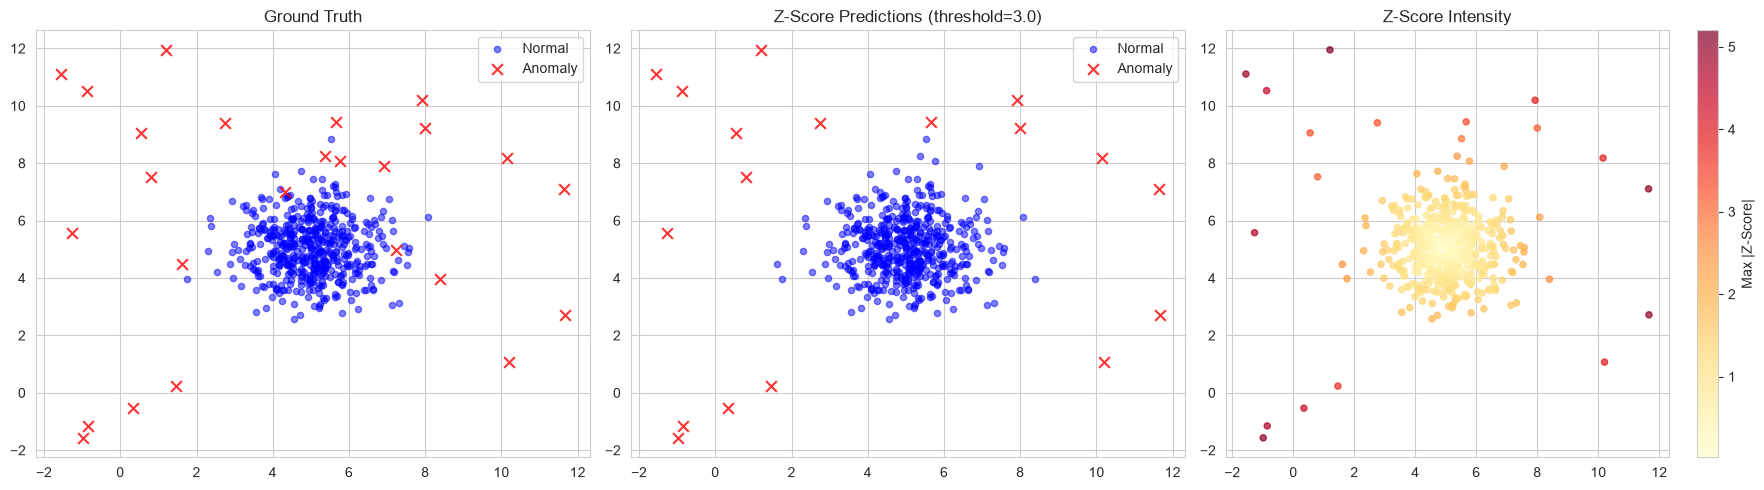

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Ground Truth
axes[0].scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='blue', alpha=0.5, s=20, label='Normal')
axes[0].scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', alpha=0.8, s=60, marker='x', label='Anomaly')
axes[0].set_title('Ground Truth')
axes[0].legend()

# Plot 2: Predicted
axes[1].scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], c='blue', alpha=0.5, s=20, label='Normal')
axes[1].scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], c='red', alpha=0.8, s=60, marker='x', label='Anomaly')
axes[1].set_title(f'Z-Score Predictions (threshold={THRESHOLD})')
axes[1].legend()

# Plot 3: Z-Score Heatmap
max_z = z_scores.max(axis=1)
scatter = axes[2].scatter(X[:, 0], X[:, 1], c=max_z, cmap='YlOrRd', alpha=0.7, s=20)
plt.colorbar(scatter, ax=axes[2], label='Max |Z-Score|')
axes[2].set_title('Z-Score Intensity')

plt.tight_layout()
plt.show()

## 5. Evaluation

In [6]:
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))
print()
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

Confusion Matrix:
[[500   0]
 [  7  18]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       500
     Anomaly       1.00      0.72      0.84        25

    accuracy                           0.99       525
   macro avg       0.99      0.86      0.92       525
weighted avg       0.99      0.99      0.99       525



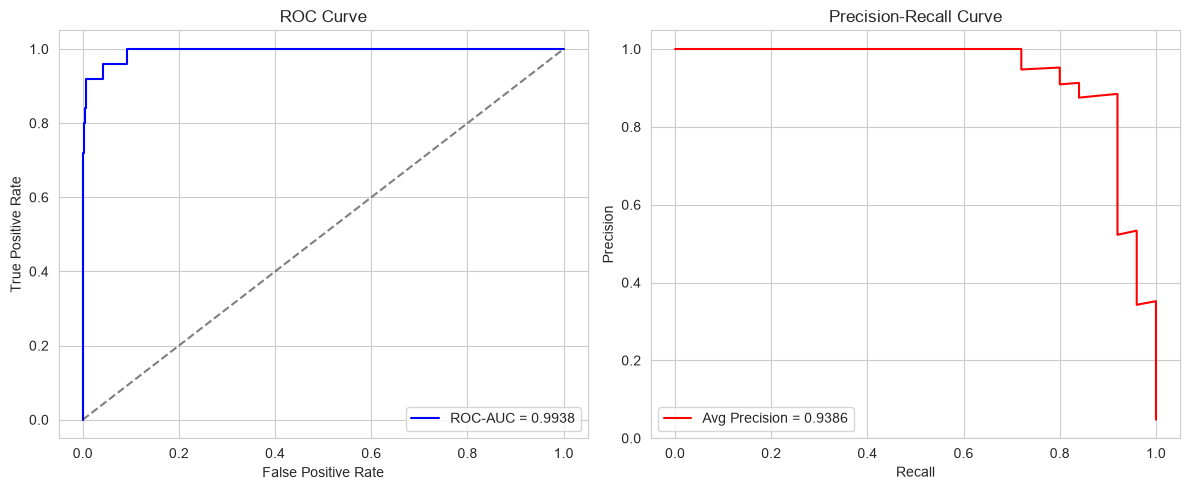

ROC-AUC: 0.9938
Average Precision: 0.9386


In [7]:
# Use max z-score as anomaly score for ROC-AUC
anomaly_scores = z_scores.max(axis=1)
roc_auc = roc_auc_score(y_true, anomaly_scores)
avg_prec = average_precision_score(y_true, anomaly_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, anomaly_scores)
axes[0].plot(fpr, tpr, 'b-', label=f'ROC-AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, anomaly_scores)
axes[1].plot(recall, precision, 'r-', label=f'Avg Precision = {avg_prec:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Average Precision: {avg_prec:.4f}')